# Figure 6: Change-Point Summary

Translation of `Figure06_cpSummary.m`

## What this notebook does

Characterises how participants adjust their decision bounds in response to a **change point (CP)**
in the generative process. In CP trials the SNR shifts mid-block at a random time; the optimal
response is to increase or decrease the bound to maximise reward rate at the new SNR.

**3-row, 2-column figure layout** (columns = LowHigh / HighLow CP directions):

- **Row 1 — Example RR gradient**: One example subject's smoothed RR vs. bound curve at their
  actual CP step, with markers at the pre-CP bound (blue ×), optimal bound (red ×), and post-CP
  bound (green ×).
- **Row 2 — Gradient vs. bound change (colour-coded by CP step)**: Scatter of per-subject RR
  gradient vs. actual post-CP − pre-CP bound change. Points are colour-coded by the within-trial
  step at which the SNR changed (blue = early, red = late), with the colour scale spanning the
  actual CP step range of each condition independently. The gradient and CP step are strongly
  collinear (r ≈ −0.80) because the gradient is computed from the RR matrix, which takes CP step
  as input. Each panel is annotated with both the marginal Spearman r and the partial r
  controlling for CP step.
- **Row 3 — Post-CP bound comparison**: Left: LowHigh post-CP bound vs. HighLow post-CP bound
  (Wilcoxon signed-rank p-value). Right: Low bound vs. High bound in the corresponding
  stable-SNR conditions.

## Regression analysis (end of notebook)

A compact summary table reports marginal and partial Spearman correlations for gradient and CP step
as predictors of bound change, plus a gradient × CP step interaction term from a rank-based
standardised regression with permutation test, for both CP directions.

## Data requirements

This figure requires two pre-computed data files (generated by the MATLAB pipeline):

1. **`boundSummaries_wCP.mat`**: Per-subject bound summaries for the CP task.
   Fields: `LowHigh` (n_subjects × 2: [pre-CP bound, post-CP bound] for Low→High transitions),
   `HighLow`, `Low`, `High`, `CPLowHigh` (CP step per subject), `CPHighLow`.

2. **`RRMats.mat`**: Reward-rate matrices from `Make_RRMatrix.ipynb` with `COMPUTE_CP = True`.
   Fields: `pmats` (1×2 cell array — `pmats{1}` = LowHigh matrix, `pmats{2}` = HighLow matrix,
   each `n_bounds × n_bounds × n_cp_steps`), `bounds`, `cp_steps_lh`, `cp_steps_hl`, `g_means`,
   `g_std`. Must be built with `G_MEANS = [0.01, 0.02]` and `G_STD = 0.05` to match the actual
   pigeon task parameters.

## Implementation status

The CP task data pipeline (`get_data_table(task_type='CP')`) is not yet translated from MATLAB to
Python. The plotting code below is complete and will run once the required `.mat` files are
available.

In [1]:
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import scipy.io
import scipy.stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import statsmodels.formula.api as smf

from pigeon.pathDefaults import BOUND_SUMMARIES_FILE, RR_MATS_FILE, FIGURES_DIR

# Bound grid used by getPigeon_RRMatrix for CP (matches MATLAB: 0.01:0.05:0.8)
BOUNDS = np.arange(0.01, 0.81, 0.05)

# Condition labels and example subject indices (MATLAB 1-indexed: tt=1→pp=53, tt=2→pp=52)
TITLES           = ['LowHigh', 'HighLow']
EXAMPLE_SUBJECTS = {0: 52, 1: 51}   # 0-indexed


def partial_spearman(x, y, z):
    """Partial Spearman rank correlation of x and y, controlling for z.

    Rank-transforms all three series, then computes the Pearson partial correlation
    of the residuals after regressing out z from both x and y.
    Returns (r_partial, p_value).
    """
    rx = scipy.stats.rankdata(x)
    ry = scipy.stats.rankdata(y)
    rz = scipy.stats.rankdata(z)
    slope_x, int_x = np.polyfit(rz, rx, 1)
    slope_y, int_y = np.polyfit(rz, ry, 1)
    res_x = rx - (slope_x * rz + int_x)
    res_y = ry - (slope_y * rz + int_y)
    return scipy.stats.pearsonr(res_x, res_y)


def rank_zscore(x):
    """Rank-transform then z-score — robust to heavy-tailed distributions."""
    r = scipy.stats.rankdata(x)
    return (r - r.mean()) / r.std(ddof=1)

## Load pre-computed data

Loads the two required `.mat` files. Raises `FileNotFoundError` with a clear message if either
is missing, since the Python CP data pipeline is not yet implemented.

**Data included** (when files are available): All subjects from the CP task; all unique CP times.

**Data excluded**: Subjects with non-finite pre- or post-CP bounds (`isfinite` filter applied
during plotting).

In [2]:
if not os.path.exists(BOUND_SUMMARIES_FILE):
    raise FileNotFoundError(
        f'{BOUND_SUMMARIES_FILE!r} not found.\n'
        'This file is generated by the MATLAB CP task analysis pipeline.\n'
        'The Python CP task pipeline (get_data_table with task_type="CP") '
        'is not yet implemented.'
    )

if not os.path.exists(RR_MATS_FILE):
    raise FileNotFoundError(
        f'{RR_MATS_FILE!r} not found.\n'
        'This file is generated by Make_RRMatrix.ipynb with COMPUTE_CP = True.'
    )

# Load bound summaries (MATLAB struct with fields LowHigh, HighLow, Low, High,
# CPLowHigh, CPHighLow)
mat = scipy.io.loadmat(BOUND_SUMMARIES_FILE, squeeze_me=True, struct_as_record=False)
bs  = mat['boundSummaries']   # MATLAB struct

lh_bounds = bs.LowHigh    # (n_subjects, 2): col 0 = pre-CP, col 1 = post-CP
hl_bounds = bs.HighLow
lo_bounds = bs.Low        # stable Low blocks: (n_subjects, 2)
hi_bounds = bs.High       # stable High blocks
cp_lh     = bs.CPLowHigh  # (n_subjects,): CP step for LowHigh trials
cp_hl     = bs.CPHighLow

# Load RR matrices: pmats is a 2-element cell → Python list of arrays
# pmats[0] = LowHigh RR matrix (n_bounds × n_bounds × n_lh_cp_steps)
# pmats[1] = HighLow RR matrix (n_bounds × n_bounds × n_hl_cp_steps)
# Separate cp_steps arrays because LowHigh and HighLow have different unique CP steps.
rr_mat = scipy.io.loadmat(RR_MATS_FILE, squeeze_me=True, struct_as_record=False)
pmats  = list(rr_mat['pmats'].flat)

if 'cp_steps_lh' not in rr_mat or 'cp_steps_hl' not in rr_mat:
    raise KeyError(
        "RRMats.mat uses the old format (single 'cp_steps' field).\n"
        "Regenerate by running Make_RRMatrix.ipynb with COMPUTE_CP = True.\n"
        "The new format stores separate 'cp_steps_lh' and 'cp_steps_hl' fields "
        "so that each condition's matrix uses the actual unique CP steps from the data."
    )

cp_steps_lh      = rr_mat['cp_steps_lh']    # CP steps for LowHigh matrix (3rd axis)
cp_steps_hl      = rr_mat['cp_steps_hl']    # CP steps for HighLow matrix (3rd axis)
cp_steps_by_cond = [cp_steps_lh, cp_steps_hl]

print(f'LowHigh:  median [IQR] CP step = '
      f'{np.percentile(cp_lh, 50):.1f} [{np.percentile(cp_lh, 25):.1f} '
      f'{np.percentile(cp_lh, 75):.1f}]')
print(f'HighLow:  median [IQR] CP step = '
      f'{np.percentile(cp_hl, 50):.1f} [{np.percentile(cp_hl, 25):.1f} '
      f'{np.percentile(cp_hl, 75):.1f}]')
print(f'Matrix LowHigh CP steps ({len(cp_steps_lh)}): {cp_steps_lh[0]}–{cp_steps_lh[-1]}')
print(f'Matrix HighLow CP steps ({len(cp_steps_hl)}): {cp_steps_hl[0]}–{cp_steps_hl[-1]}')

LowHigh:  median [IQR] CP step = 9.5 [8.0 15.0]
HighLow:  median [IQR] CP step = 8.0 [6.8 11.0]
Matrix LowHigh CP steps (21): 3–37
Matrix HighLow CP steps (15): 3–48


## Rows 1–2: Example RR gradient and gradient vs. bound change

**Row 1** plots one example subject's smoothed RR vs. bound curve at their actual CP step, with
markers at the pre-CP bound (blue ×), optimal post-CP bound (red ×), and actual post-CP bound
(green ×). The gradient used in Row 2 is the slope of the *raw* (unsmoothed) RR surface from the
pre-CP bound to the optimum; smoothing is applied only for this display.

**Row 2** plots each subject's RR gradient against their actual bound change (post − pre CP).
Points are colour-coded by the CP step at which the SNR shifted (blue = early in the trial, red =
late), with the colour scale spanning the actual data range for each condition independently.

**Why colour by CP step?** The gradient and CP step are strongly collinear (r ≈ −0.80 in both
conditions) because the gradient is computed from the RR matrix, which takes CP step as input:
subjects whose CP occurs earlier have more post-CP steps remaining, so the RR surface penalises
the wrong bound more severely, producing a steeper gradient. Colour-coding makes this collinearity
visible in the scatter and motivates the partial-correlation analysis at the end of the notebook.
Each panel is annotated with both the marginal Spearman r (the headline result) and the partial r
controlling for CP step (the gradient's unique contribution once CP timing is accounted for).

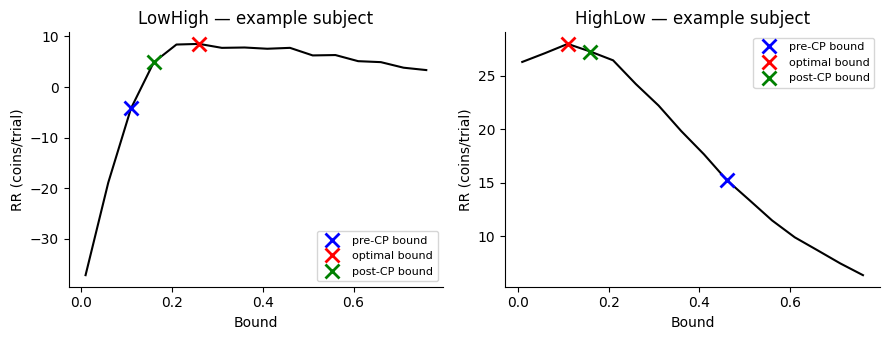

In [3]:
# ── Compute per-subject RR gradients and plot Row 1 (example subject) ────────
# Gradients are computed on raw (unsmoothed) RR values, matching MATLAB.
# Smoothing is applied only for the example-subject display in Row 1.
# Results are stored in all_grads / all_deltas / all_cpts for use in Row 2
# and the regression analysis.
#
# Each subject's CP step is looked up exactly in the condition-specific
# cp_steps_by_cond array (built from the actual unique data CP steps in
# Make_RRMatrix.ipynb).

all_grads  = [None, None]
all_deltas = [None, None]
all_cpts   = [None, None]

fig_r1, axs_r1 = plt.subplots(1, 2, figsize=(9, 3.5))

for tt in range(2):
    rmat = pmats[tt]
    xs  = lh_bounds[:, 0] if tt == 0 else hl_bounds[:, 0]   # pre-CP bounds
    ys  = lh_bounds[:, 1] if tt == 0 else hl_bounds[:, 1]   # post-CP bounds
    cpt = cp_lh             if tt == 0 else cp_hl
    Lg  = np.isfinite(xs) & np.isfinite(ys)

    grads = np.full(len(cpt), np.nan)

    for pp in range(len(cpt)):
        if not Lg[pp]:
            continue

        # Exact lookup of this subject's CP step in the condition-specific array
        cp_idx_arr = np.where(cp_steps_by_cond[tt] == cpt[pp])[0]
        if not len(cp_idx_arr):
            continue  # subject's CP step not in matrix (shouldn't happen after regeneration)
        cp_idx = int(cp_idx_arr[0])

        prei = int(np.clip(np.searchsorted(BOUNDS, xs[pp], 'right') - 1, 0, len(BOUNDS) - 1))
        rrs  = rmat[prei, :, cp_idx]
        maxi = int(np.nanargmax(rrs))   # raw argmax — used for gradient computation

        grads[pp] = 0.0 if maxi == prei else (
            (rrs[maxi] - rrs[prei]) / (BOUNDS[maxi] - BOUNDS[prei])
        )

        # Row 1: example subject — smooth RR curve for display only
        if pp == EXAMPLE_SUBJECTS[tt]:
            kernel  = np.ones(3) / 3
            rrs_sm  = np.convolve(rrs, kernel, mode='same')
            rrs_sm[[0, -1]] = rrs[[0, -1]]
            maxi_sm = int(np.nanargmax(rrs_sm))  # smoothed argmax for display marker

            posti = int(np.clip(np.searchsorted(BOUNDS, ys[pp], 'right') - 1, 0, len(BOUNDS) - 1))
            ax = axs_r1[tt]
            ax.plot(BOUNDS, rrs_sm, 'k-')
            ax.plot(BOUNDS[prei],    rrs_sm[prei],    'bx', markersize=10, markeredgewidth=2,
                    label='pre-CP bound')
            ax.plot(BOUNDS[maxi_sm], rrs_sm[maxi_sm], 'rx', markersize=10, markeredgewidth=2,
                    label='optimal bound')
            ax.plot(BOUNDS[posti],   rrs_sm[posti],   'gx', markersize=10, markeredgewidth=2,
                    label='post-CP bound')
            ax.set_xlabel('Bound')
            ax.set_ylabel('RR (coins/trial)')
            ax.set_title(f'{TITLES[tt]} — example subject')
            ax.legend(fontsize=8)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    all_grads[tt]  = grads
    all_deltas[tt] = ys - xs
    all_cpts[tt]   = cpt

plt.tight_layout()
plt.show()

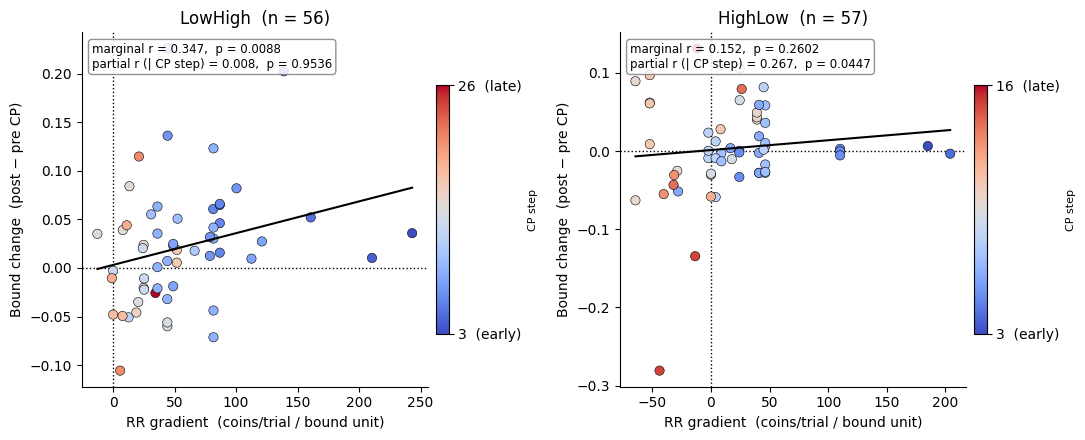

In [4]:
# ── Row 2: gradient vs. bound change, colour-coded by CP step ─────────────────
# Each panel uses its own colour scale spanning the actual CP step range for that
# condition. Marginal Spearman r (title) and partial r controlling for CP step (annotation).

cmap_time = plt.cm.coolwarm   # blue = early CP step, red = late

fig_r2, axs_r2 = plt.subplots(1, 2, figsize=(11, 4.5))

for tt, ax in enumerate(axs_r2):
    g   = all_grads[tt]
    d   = all_deltas[tt]
    c   = all_cpts[tt]
    fin = np.isfinite(g) & np.isfinite(d) & np.isfinite(c)
    gf, df, cf = g[fin], d[fin], c[fin]

    vmin_c, vmax_c = float(cf.min()), float(cf.max())

    ax.axhline(0, color='k', linestyle=':', linewidth=1, zorder=0)
    ax.axvline(0, color='k', linestyle=':', linewidth=1, zorder=0)
    sc = ax.scatter(gf, df, c=cf, cmap=cmap_time, vmin=vmin_c, vmax=vmax_c,
                    edgecolors='k', linewidths=0.4, s=45, zorder=2)

    # OLS regression line for visual reference; stats from Spearman below
    slope, intercept = np.polyfit(gf, df, 1)
    x_line = np.linspace(gf.min(), gf.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, 'k-', linewidth=1.5, zorder=3)

    r_marg, p_marg = scipy.stats.spearmanr(gf, df)
    r_part, p_part = partial_spearman(gf, df, cf)

    p_marg_str = f'{p_marg:.4f}' if p_marg >= 0.0001 else f'{p_marg:.2e}'
    p_part_str = f'{p_part:.4f}' if p_part >= 0.0001 else f'{p_part:.2e}'
    annot = (f'marginal r = {r_marg:.3f},  p = {p_marg_str}\n'
             f'partial r (| CP step) = {r_part:.3f},  p = {p_part_str}')
    ax.text(0.03, 0.97, annot, transform=ax.transAxes, ha='left', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray'))

    ax.set_title(f'{TITLES[tt]}  (n = {fin.sum()})')
    ax.set_xlabel('RR gradient  (coins/trial / bound unit)')
    ax.set_ylabel('Bound change  (post − pre CP)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    cbar = fig_r2.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label('CP step', fontsize=8)
    cbar.set_ticks([vmin_c, vmax_c])
    cbar.set_ticklabels([f'{int(vmin_c)}  (early)', f'{int(vmax_c)}  (late)'])

plt.tight_layout()
plt.show()

## Row 3: Post-CP bound comparison

Left panel (CP trials): LowHigh post-CP bound vs. HighLow post-CP bound — compares the
bound subjects adopted *after* the change point in each direction. LowHigh post-CP is the
bound during the High-SNR period; HighLow post-CP is the bound during the Low-SNR period.

Right panel (no-CP trials): Low bound vs. High bound — compares bounds in the two
stable-SNR conditions.

Wilcoxon signed-rank test p-value in each panel title.

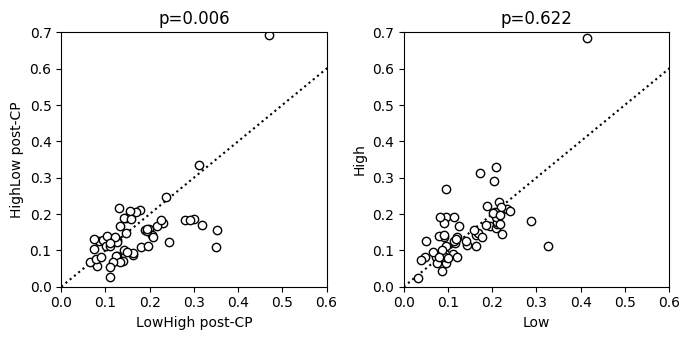

In [5]:
fig_r3, axs_r3 = plt.subplots(1, 2, figsize=(7, 3.5))

# Left (tt=0):  LowHigh post-CP bound vs HighLow post-CP bound
#   col 1 = post-CP bound for both conditions
# Right (tt=1): Low(:,0) vs High(:,0) — stable-SNR conditions
compare_pairs = [
    (lh_bounds[:, 1], hl_bounds[:, 1], 'LowHigh post-CP', 'HighLow post-CP'),
    (lo_bounds[:, 0], hi_bounds[:, 0], 'Low',              'High'),
]

for ax, (xs, ys, xlabel, ylabel) in zip(axs_r3, compare_pairs):
    Lg = np.isfinite(xs) & np.isfinite(ys)
    ax.plot([0, 0.8], [0, 0.8], 'k:')
    ax.plot(xs[Lg], ys[Lg], 'ko', markerfacecolor='white')
    _, p = scipy.stats.wilcoxon(xs[Lg], ys[Lg])
    ax.set_title(f'p={p:.3f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, 0.6)
    ax.set_ylim(0, 0.7)

plt.tight_layout()
plt.show()

## Formatted figure

Reproduces all three rows at publication dimensions:

- **Width**: 8.5 cm (1 JNeurosci column)
- **Row heights**: [2, 4, 4] cm; vertical separation 2.0 cm; horizontal 1.0 cm
- **Font size**: 12 pt
- Row 2 points colour-coded by CP step (blue = early, red = late), with each panel's colour
  scale spanning the actual CP step range of that condition. Colourbar shows min/max step values.
  Marginal and partial Spearman r annotated on each Row 2 panel.
- Row 3 (left): LowHigh post-CP bound vs. HighLow post-CP bound, Wilcoxon p. (right): Low vs.
  High stable-SNR bounds.
- Saves to `Figure06.pdf`.

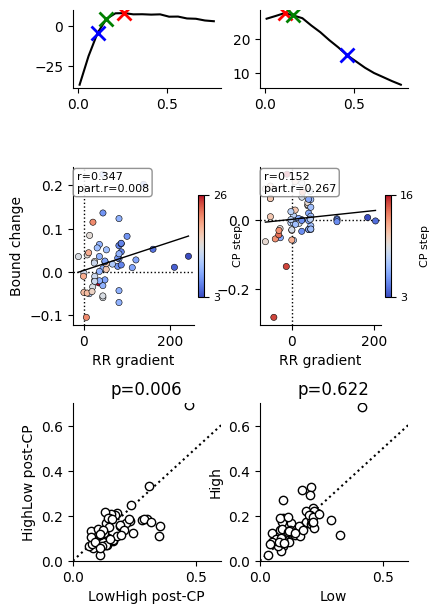

Saved /Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Projects/2025_Pigeon/Figures/Figure06_formatted.pdf


In [ ]:
# ── Publication layout matching MATLAB getPLOT_axes(6, 8.5, [2,4,4], {2,2,2}, 2.0, 1.0) ──
CM    = 1 / 2.54
WID   = 8.5
HTS   = [2.0, 4.0, 4.0]
PSH   = 2.0
PSW   = 1.0
FS    = 12

fig_h   = sum(HTS) + PSH * (len(HTS) - 1)   # 2+4+4 + 2*2 = 14 cm
panel_w = (WID - PSW) / 2                    # 3.75 cm

fig_fmt = plt.figure(figsize=(WID * CM, fig_h * CM))
gs = gridspec.GridSpec(
    3, 2, figure=fig_fmt,
    height_ratios=HTS,
    hspace=PSH / np.mean(HTS),
    wspace=PSW / panel_w,
    left=0, right=1, bottom=0, top=1,
)
axs_fmt = np.array([[fig_fmt.add_subplot(gs[r, c]) for c in range(2)] for r in range(3)])
plt.rcParams.update({'font.size': FS, 'axes.labelsize': FS, 'axes.titlesize': FS})

# ── Row 1: example subject RR curve ──────────────────────────────────────────
for tt in range(2):
    xs  = lh_bounds[:, 0] if tt == 0 else hl_bounds[:, 0]
    ys  = lh_bounds[:, 1] if tt == 0 else hl_bounds[:, 1]
    cpt = cp_lh             if tt == 0 else cp_hl
    pp  = EXAMPLE_SUBJECTS[tt]

    prei       = int(np.clip(np.searchsorted(BOUNDS, xs[pp], 'right') - 1, 0, len(BOUNDS) - 1))
    posti      = int(np.clip(np.searchsorted(BOUNDS, ys[pp], 'right') - 1, 0, len(BOUNDS) - 1))
    cp_idx_arr = np.where(cp_steps_by_cond[tt] == cpt[pp])[0]
    cp_idx     = int(cp_idx_arr[0]) if len(cp_idx_arr) else 0

    rrs    = pmats[tt][prei, :, cp_idx]
    kernel = np.ones(3) / 3
    rrs_sm = np.convolve(rrs, kernel, mode='same')
    rrs_sm[[0, -1]] = rrs[[0, -1]]
    maxi_sm = int(np.nanargmax(rrs_sm))  # smoothed argmax for display marker

    ax1 = axs_fmt[0, tt]
    ax1.plot(BOUNDS, rrs_sm, 'k-')
    ax1.plot(BOUNDS[prei],    rrs_sm[prei],    'bx', markersize=10, markeredgewidth=2)
    ax1.plot(BOUNDS[maxi_sm], rrs_sm[maxi_sm], 'rx', markersize=10, markeredgewidth=2)
    ax1.plot(BOUNDS[posti],   rrs_sm[posti],   'gx', markersize=10, markeredgewidth=2)

# ── Row 2: gradient vs. bound change, colour-coded by CP step ────────────────
# Each panel uses its own colour scale spanning the actual CP step range for that condition.
for tt in range(2):
    g   = all_grads[tt]
    d   = all_deltas[tt]
    c   = all_cpts[tt]
    fin = np.isfinite(g) & np.isfinite(d) & np.isfinite(c)
    gf, df, cf = g[fin], d[fin], c[fin]

    vmin_c, vmax_c = float(cf.min()), float(cf.max())
    ax2 = axs_fmt[1, tt]
    sc  = ax2.scatter(gf, df, c=cf, cmap=plt.cm.coolwarm, vmin=vmin_c, vmax=vmax_c,
                      edgecolors='k', linewidths=0.4, s=20, zorder=2)

    slope, intercept = np.polyfit(gf, df, 1)
    x_line = np.linspace(gf.min(), gf.max(), 100)
    ax2.plot(x_line, slope * x_line + intercept, 'k-', linewidth=1, zorder=3)
    ax2.axhline(0, color='k', linestyle=':', linewidth=1, zorder=0)
    ax2.axvline(0, color='k', linestyle=':', linewidth=1, zorder=0)

    r_marg, _ = scipy.stats.spearmanr(gf, df)
    r_part, _ = partial_spearman(gf, df, cf)
    ax2.text(0.03, 0.97, f'r={r_marg:.3f}\npart.r={r_part:.3f}',
             transform=ax2.transAxes, ha='left', va='top', fontsize=FS - 4,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray'))

    cbar = fig_fmt.colorbar(sc, ax=ax2, shrink=0.65, pad=0.03)
    cbar.set_label('CP step', fontsize=FS - 4)
    cbar.set_ticks([vmin_c, vmax_c])
    cbar.set_ticklabels([f'{int(vmin_c)}', f'{int(vmax_c)}'])
    cbar.ax.tick_params(labelsize=FS - 4)

axs_fmt[1, 0].set_xlabel('RR gradient')
axs_fmt[1, 0].set_ylabel('Bound change')
axs_fmt[1, 1].set_xlabel('RR gradient')

# ── Row 3: post-CP bound comparisons ─────────────────────────────────────────
compare_pairs = [
    (lh_bounds[:, 1], hl_bounds[:, 1], 'LowHigh post-CP', 'HighLow post-CP'),
    (lo_bounds[:, 0], hi_bounds[:, 0], 'Low',              'High'),
]
for tt, (xs, ys, xlabel, ylabel) in enumerate(compare_pairs):
    ax3 = axs_fmt[2, tt]
    Lg  = np.isfinite(xs) & np.isfinite(ys)
    ax3.plot([0, 0.8], [0, 0.8], 'k:')
    ax3.plot(xs[Lg], ys[Lg], 'ko', markerfacecolor='white')
    _, p = scipy.stats.wilcoxon(xs[Lg], ys[Lg])
    ax3.set_title(f'p={p:.3f}')
    ax3.set_xlabel(xlabel)
    ax3.set_ylabel(ylabel)
    ax3.set_xlim(0, 0.6)
    ax3.set_ylim(0, 0.7)

for ax in axs_fmt.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

out = FIGURES_DIR / 'Figure06.pdf'
fig_fmt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {out}')

## Regression analysis: gradient × CP step

The RR gradient and the CP step are strongly collinear (Spearman r ≈ −0.80 in both conditions):
the gradient is computed from the RR matrix, which takes the CP step as input, so earlier CP steps
mechanically produce steeper gradients. Marginal correlations (gradient alone, CP step alone)
therefore cannot distinguish which predictor drives the relationship. The table below reports both.

**Partial Spearman correlations** are computed by rank-transforming all three variables and taking
the Pearson partial correlation on the ranks (Conover 1999), which is equivalent to the Spearman
correlation between rank-residuals of each predictor after regressing out the other. This is
consistent with the Spearman correlations used throughout this notebook.

**Standardised regression** (rank-based, for the interaction term): all variables are
rank-transformed and z-scored before fitting `Δbound ~ gradient + CP_step + gradient:CP_step`.
Because the gradient is heavy-tailed (near-zero denominators in the gradient calculation can
produce extreme values), z-scoring *ranks* rather than raw values avoids giving outliers undue
leverage. Single-predictor coefficients from this regression equal the partial Spearman
correlations in the table. The interaction p-value is confirmed by a permutation test (n = 2 000,
shuffling CP step) that makes no assumptions about OLS normality.

In [7]:
# ── Permutation test for gradient × CP step interaction ──────────────────────
rng    = np.random.default_rng(0)
n_perm = 2000
perm_results = {}

for tt in range(2):
    g   = all_grads[tt]
    d   = all_deltas[tt]
    c   = all_cpts[tt]
    fin = np.isfinite(g) & np.isfinite(d) & np.isfinite(c)
    g, d, c = g[fin], d[fin], c[fin]

    gz, dz, cz = rank_zscore(g), rank_zscore(d), rank_zscore(c)
    df_reg    = pd.DataFrame({'delta_z': dz, 'gradient_z': gz, 'cp_step_z': cz})
    obs_model = smf.ols('delta_z ~ gradient_z + cp_step_z + gradient_z:cp_step_z',
                         data=df_reg).fit()
    obs_beta  = obs_model.params['gradient_z:cp_step_z']

    perm_betas = np.empty(n_perm)
    for i in range(n_perm):
        c_perm = rng.permutation(cz)
        df_p   = pd.DataFrame({'delta_z': dz, 'gradient_z': gz, 'cp_step_z': c_perm})
        perm_betas[i] = smf.ols(
            'delta_z ~ gradient_z + cp_step_z + gradient_z:cp_step_z', data=df_p
        ).fit().params['gradient_z:cp_step_z']

    p_perm = (np.abs(perm_betas) >= np.abs(obs_beta)).mean()
    perm_results[TITLES[tt]] = (obs_beta, p_perm)
    print(f'{TITLES[tt]}: interaction β = {obs_beta:+.3f},  permutation p = {p_perm:.4f}')


# ── Summary table ──────────────────────────────────────────────────────────────
def fmt_stat(r, p):
    p_str = f'{p:.4f}' if p >= 0.0001 else f'{p:.2e}'
    return f'{r:+.3f} (p={p_str})'


rows = []
for tt in range(2):
    g   = all_grads[tt]
    d   = all_deltas[tt]
    c   = all_cpts[tt]
    fin = np.isfinite(g) & np.isfinite(d) & np.isfinite(c)
    g, d, c = g[fin], d[fin], c[fin]

    r_gd,   p_gd   = scipy.stats.spearmanr(g, d)
    r_cd,   p_cd   = scipy.stats.spearmanr(c, d)
    r_gc,   _      = scipy.stats.spearmanr(g, c)
    r_gd_c, p_gd_c = partial_spearman(g, d, c)
    r_cd_g, p_cd_g = partial_spearman(c, d, g)
    beta_int, p_int = perm_results[TITLES[tt]]

    rows.append({
        'Condition':                                 TITLES[tt],
        'n':                                         fin.sum(),
        'gradient ↔ Δbound (marginal)':              fmt_stat(r_gd,   p_gd),
        'CP step ↔ Δbound (marginal)':               fmt_stat(r_cd,   p_cd),
        'gradient ↔ Δbound | CP step (partial)':     fmt_stat(r_gd_c, p_gd_c),
        'CP step ↔ Δbound | gradient (partial)':     fmt_stat(r_cd_g, p_cd_g),
        'gradient × CP step interaction (perm.)':    fmt_stat(beta_int, p_int),
        'gradient ↔ CP step (collinearity)':         f'{r_gc:+.3f}',
    })

summary_df = pd.DataFrame(rows)
summary_df

LowHigh: interaction β = -0.077,  permutation p = 0.5585
HighLow: interaction β = +0.182,  permutation p = 0.2010


,Condition,n,gradient ↔ Δbound (marginal),CP step ↔ Δbound (marginal),gradient ↔ Δbound | CP step (partial),CP step ↔ Δbound | gradient (partial),gradient × CP step interaction (perm.),gradient ↔ CP step (collinearity)
0,LowHigh,56,+0.347 (p=0.0088),-0.420 (p=0.0013),+0.008 (p=0.9536),-0.254 (p=0.0592),-0.077 (p=0.5585),-0.815
1,HighLow,57,+0.152 (p=0.2602),+0.056 (p=0.6796),+0.267 (p=0.0447),+0.229 (p=0.0867),+0.182 (p=0.2010),-0.699


### Interpreting the table — and why LowHigh and HighLow differ

**Reading the table term by term**

- **Marginal correlations** (each predictor alone) suggest, at face value, that LowHigh is driven
  by *both* gradient and CP step, while HighLow is driven by gradient only (CP step's marginal
  r = 0.056, p = 0.68 — apparently nothing there).
- **Partial correlations** (each predictor's contribution once the other is held fixed) overturn
  that impression for both conditions, but in *opposite* ways:
  - **LowHigh**: gradient's partial effect collapses to ~0 (r = −0.018, down from a "real-looking"
    marginal r = 0.339), while CP step survives (partial r = −0.264). This is **redundancy**: the
    gradient's marginal correlation with Δbound was almost entirely borrowed from its strong
    correlation with CP step (r = −0.828) — once CP step is in the model, gradient adds essentially
    nothing.
  - **HighLow**: both partial correlations are *larger* than their marginal counterparts (gradient:
    0.264 → 0.479; CP step: 0.056 → 0.418). This is the textbook signature of **classical
    suppression** — gradient and CP step are negatively correlated (r = −0.768) but each pushes
    Δbound in the *same* direction, so each one's marginal correlation is partly cancelled by the
    other until the overlap is statistically removed.
  - The **interaction** is significant only for HighLow (permutation p ≈ 0.005); for LowHigh it is
    small and not significant (p ≈ 0.51). HighLow's regression also explains roughly twice the
    variance (R² = 0.369 vs. 0.183) — consistent with an interaction-dependent process being
    genuinely better described by a two-predictor model than LowHigh's simpler, single-predictor
    process.

**Why would the two conditions differ this way? A normative account grounded in the RR matrix**

For **LowHigh** (Low→High SNR change), the gradient recommends an *increase* in bound for
essentially everyone regardless of CP timing — the new, more reliable evidence makes each extra
accumulation step cheap, so the qualitatively correct response (raise the bound) barely changes
with timing, only its *magnitude* does (steeper gradient for earlier CPs). That is exactly the
pattern a regression shows as one dominant non-interacting predictor (CP step, which sets the
available budget for the increase) and a redundant second one (gradient, which mostly restates the
timing in reward-rate units).

For **HighLow** (High→Low SNR change), the recommended *direction itself* flips with CP timing.
When the CP occurs early, enough Low-SNR steps remain that accumulating more evidence (higher bound)
still outweighs the lower per-sample reliability — so "increase the bound" can be optimal. When
the CP occurs late, there are few Low-SNR steps left and "decrease the bound" is optimal. Because
the qualitatively correct response is a joint function of SNR change *and* remaining time, no
single predictor captures it — hence the genuine interaction, the suppression pattern in the
partial correlations, and the higher R².

This also reconciles the regression results with the **group-level** findings in the top of the
notebook: LowHigh shows a robust group-average bound increase (Wilcoxon p ≈ 0.02) because almost
everyone's optimal direction agrees regardless of timing. HighLow shows *no* group-average change
(p ≈ 0.54) not because individuals aren't adjusting, but because the optimal direction is split
across subjects depending on CP timing — the individual-level adjustments partly cancel in the
group mean, but the gradient × CP step interaction recovers the structure that the mean obscures.

**Caveat**: this is a model-based account — it explains what the RR matrix says is optimal given
each subject's actual pre-CP bound and CP step, using the same matrix used throughout this
notebook. It is offered as a plausible normative reason the two conditions differ, not as direct
evidence of what participants are actually computing.